In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)

# Other baseline models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Our model of choice
from xgboost import XGBClassifier

In [2]:
# ========================================================================= #
# STEP ONE: Modeling
# ========================================================================= #

In [3]:
# ------------------------------------------------------------ #
# Load dataset
# ------------------------------------------------------------ #
master = pd.read_csv("master_geomagnetic_1hour.csv")
master["datetime"] = pd.to_datetime(master["datetime"])

# ------------------------------------------------------------ #
# Define leakage columns
# ------------------------------------------------------------ #
leakage_cols = [
    "datetime",
    "Kp_omni",
    "Kp",
    "kp_future_6h_max",
    "storm_next_6h",
    "storm_now",
    "hours_until_storm",
    "Kp_gst",
    "gstID",
    "startTime",
]

leakage_cols = [col for col in leakage_cols if col in master.columns]

PERSISTENCE_COLS = [
    "kp_past_3h_max",
    "kp_past_6h_max",
    "storm_past_3h",
    "storm_past_6h"
]

# ------------------------------------------------------------ #
# [!!!] Evaluation helper [!!!]
# ------------------------------------------------------------ #
def evaluate_model(model, X_data, y_data, threshold=0.5, name="Model"):
    """
    Evaluates one trained model at one decision threshold.

    The model outputs probabilities first. Those probabilities are converted
    into storm / non-storm predictions using the selected threshold. Lower
    thresholds usually catch more storms, while higher thresholds make fewer
    but more confident storm predictions.
    """
    probs = model.predict_proba(X_data)[:, 1]
    preds = (probs >= threshold).astype(int)

    auc = roc_auc_score(y_data, probs)
    precision = precision_score(y_data, preds, zero_division=0)
    recall = recall_score(y_data, preds, zero_division=0)
    f1 = f1_score(y_data, preds, zero_division=0)
    cm = confusion_matrix(y_data, preds)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print("ROC-AUC:", round(auc, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1:", round(f1, 4))
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_data, preds, zero_division=0))

    return probs, preds

def prepare_data(master, remove_persistence=False):
    """
    Builds train, validation, and test sets using time-based splitting.

    The split avoids random shuffling because this is a forecasting problem.
    Training uses earlier years, validation uses the middle years for model/
    threshold checks, and testing uses later years to simulate future prediction.
    """
    X = master.drop(columns=leakage_cols)
    y = master["storm_next_6h"]

    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)

    if remove_persistence:
        X = X.drop(
            columns=[col for col in PERSISTENCE_COLS if col in X.columns]
        )

    # Model learns patterns from 2010-2018
    train_mask = master["datetime"] < "2019-01-01"

    # Validation to tune threshold/model choices
    val_mask = (
        (master["datetime"] >= "2019-01-01") &
        (master["datetime"] < "2022-01-01")
    )

    # Evaluation of future
    test_mask = master["datetime"] >= "2022-01-01"

    X_train = X.loc[train_mask].copy()
    y_train = y.loc[train_mask].copy()

    X_val = X.loc[val_mask].copy()
    y_val = y.loc[val_mask].copy()

    X_test = X.loc[test_mask].copy()
    y_test = y.loc[test_mask].copy()

    train_medians = X_train.median()

    X_train = X_train.fillna(train_medians)
    X_val = X_val.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    return X_train, X_val, X_test, y_train, y_val, y_test

def train_xgb(X_train, y_train):
    """
    Trains an XGBoost classifier for rare storm-event prediction.

    scale_pos_weight is computed from the training data so the model gives
    more importance to the rare positive storm class.
    """
    negative_count = (y_train == 0).sum()
    positive_count = (y_train == 1).sum()

    scale_pos_weight = negative_count / positive_count

    model = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )

    model.fit(X_train, y_train)
    return model

def train_logistic_regression(X_train, y_train):
    """
    Trains a balanced logistic regression baseline.

    StandardScaler is used because logistic regression is sensitive to feature
    scale. class_weight="balanced" helps account for the low storm rate.
    """
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000
        ))
    ])

    model.fit(X_train, y_train)
    return model


def train_random_forest(X_train, y_train):
    """
    Trains a random forest classifier as a nonlinear tree-based baseline.

    The max_depth and min_samples_leaf values keep the model from becoming
    too complex, while class_weight='balanced' helps with class imbalance.
    """
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    return model

# ------------------------------------------------------------ #
# WITH persistence
# ------------------------------------------------------------ #
X_train_p, X_val_p, X_test_p, y_train_p, y_val_p, y_test_p = prepare_data(
    master,
    remove_persistence=False
)
log_with_persistence = train_logistic_regression(X_train_p, y_train_p)
rf_with_persistence = train_random_forest(X_train_p, y_train_p)
xgb_with_persistence = train_xgb(X_train_p, y_train_p)

# ------------------------------------------------------------ #
# WITHOUT persistence
# ------------------------------------------------------------ #
X_train_np, X_val_np, X_test_np, y_train_np, y_val_np, y_test_np = prepare_data(
    master,
    remove_persistence=True
)
log_without_persistence = train_logistic_regression(X_train_np, y_train_np)
rf_without_persistence = train_random_forest(X_train_np, y_train_np)
xgb_without_persistence = train_xgb(X_train_np, y_train_np)

print("WITH persistence:", X_train_p.shape)
print("WITHOUT persistence:", X_train_np.shape)

models = [
    ("LogReg WITH Persistence", log_with_persistence, X_test_p, y_test_p),
    ("Random Forest WITH Persistence", rf_with_persistence, X_test_p, y_test_p),
    ("XGBoost WITH Persistence", xgb_with_persistence, X_test_p, y_test_p),

    ("LogReg WITHOUT Persistence", log_without_persistence, X_test_np, y_test_np),
    ("Random Forest WITHOUT Persistence", rf_without_persistence, X_test_np, y_test_np),
    ("XGBoost WITHOUT Persistence", xgb_without_persistence, X_test_np, y_test_np),
]

for name, model, X_data, y_data in models:
    for t in [0.30, 0.50, 0.80]:
        evaluate_model(
            model,
            X_data,
            y_data,
            threshold=t,
            name=f"{name} | Test threshold={t}"
        )

models_val = [
    ("LogReg WITH Persistence", log_with_persistence, X_val_p, y_val_p),
    ("Random Forest WITH Persistence", rf_with_persistence, X_val_p, y_val_p),
    ("XGBoost WITH Persistence", xgb_with_persistence, X_val_p, y_val_p),

    ("LogReg WITHOUT Persistence", log_without_persistence, X_val_np, y_val_np),
    ("Random Forest WITHOUT Persistence", rf_without_persistence, X_val_np, y_val_np),
    ("XGBoost WITHOUT Persistence", xgb_without_persistence, X_val_np, y_val_np),
]

for name, model, X_data, y_data in models_val:
    for t in [0.30, 0.50, 0.80]:
        evaluate_model(
            model,
            X_data,
            y_data,
            threshold=t,
            name=f"{name} | Validation threshold={t}"
        )

WITH persistence: (76652, 36)
WITHOUT persistence: (76652, 32)

LogReg WITH Persistence | Test threshold=0.3
ROC-AUC: 0.9143
Precision: 0.1383
Recall: 0.9293
F1: 0.2408

Confusion Matrix:
[[21957 13017]
 [  159  2089]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.63      0.77     34974
           1       0.14      0.93      0.24      2248

    accuracy                           0.65     37222
   macro avg       0.57      0.78      0.50     37222
weighted avg       0.94      0.65      0.74     37222


LogReg WITH Persistence | Test threshold=0.5
ROC-AUC: 0.9143
Precision: 0.2078
Recall: 0.8812
F1: 0.3362

Confusion Matrix:
[[27420  7554]
 [  267  1981]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.78      0.88     34974
           1       0.21      0.88      0.34      2248

    accuracy                           0.79     37222
   macro avg       0.60      0.8

In [ ]:
# ========================================================================= #
# STEP TWO: Model evaluation
# ========================================================================= #

In [4]:
# ------------------------------------------------------------ #
# PURELY BASED ON XGBOOST!!!
# ------------------------------------------------------------ #
# WITH persistence
probs_with = xgb_with_persistence.predict_proba(X_test_p)[:, 1]

# WITHOUT persistence
probs_without = xgb_without_persistence.predict_proba(X_test_np)[:, 1]

thresholds = np.linspace(0.1, 0.9, 30)

def compute_metrics(y_true, probs, thresholds):
    data = []
    for t in thresholds:
        preds = (probs >= t).astype(int)

        precision = precision_score(y_true, preds, zero_division=0)
        recall = recall_score(y_true, preds, zero_division=0)
        f1 = f1_score(y_true, preds, zero_division=0)

        data.append((t, precision, recall, f1))

    return pd.DataFrame(data, columns=["threshold","precision","recall","f1"])

df_with = compute_metrics(y_test_p, probs_with, thresholds)
df_without = compute_metrics(y_test_np, probs_without, thresholds)

In [5]:
# ------------------------------------------------------------ #
# Threshold Comparison
# ------------------------------------------------------------ #
def plot_threshold_comparison(df_with, df_without):
    plt.figure(figsize=(8,5))

    plt.plot(df_with["threshold"], df_with["recall"], label="Recall WITH")
    plt.plot(df_without["threshold"], df_without["recall"], label="Recall WITHOUT")

    plt.plot(df_with["threshold"], df_with["precision"], "--", label="Precision WITH")
    plt.plot(df_without["threshold"], df_without["precision"], "--", label="Precision WITHOUT")

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("XGBoost Threshold Tradeoff Comparison")
    plt.legend()
    plt.grid()
    plt.show()

# ------------------------------------------------------------ #
# ROC Curve Comparison
# ------------------------------------------------------------ #
def plot_roc_comparison(y_with, probs_with, y_without, probs_without):
    fpr_w, tpr_w, _ = roc_curve(y_with, probs_with)
    fpr_wo, tpr_wo, _ = roc_curve(y_without, probs_without)

    auc_w = auc(fpr_w, tpr_w)
    auc_wo = auc(fpr_wo, tpr_wo)

    plt.figure(figsize=(7,5))
    plt.plot(fpr_w, tpr_w, label=f"WITH Persistence (AUC={auc_w:.3f})")
    plt.plot(fpr_wo, tpr_wo, label=f"WITHOUT Persistence (AUC={auc_wo:.3f})")
    plt.plot([0,1],[0,1],'--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("Recall")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.grid()
    plt.show()

# ------------------------------------------------------------ #
# Precision-Recall Curve
# ------------------------------------------------------------ #
def plot_pr_comparison(y_with, probs_with, y_without, probs_without):
    p_w, r_w, _ = precision_recall_curve(y_with, probs_with)
    p_wo, r_wo, _ = precision_recall_curve(y_without, probs_without)

    ap_w = average_precision_score(y_with, probs_with)
    ap_wo = average_precision_score(y_without, probs_without)

    plt.figure(figsize=(7,5))
    plt.plot(r_w, p_w, label=f"WITH (AP={ap_w:.3f})")
    plt.plot(r_wo, p_wo, label=f"WITHOUT (AP={ap_wo:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.grid()
    plt.show()

# ------------------------------------------------------------ #
# Feature Importance
# ------------------------------------------------------------ #
def plot_feature_importance_comparison(model_with, model_without, X_with, X_without):
    imp_with = pd.DataFrame({
        "feature": X_with.columns,
        "importance": model_with.feature_importances_
    }).sort_values("importance", ascending=False).head(15)

    imp_without = pd.DataFrame({
        "feature": X_without.columns,
        "importance": model_without.feature_importances_
    }).sort_values("importance", ascending=False).head(15)

    fig, axes = plt.subplots(1,2, figsize=(14,6))

    axes[0].barh(imp_with["feature"][::-1], imp_with["importance"][::-1])
    axes[0].set_title("WITH Persistence")

    axes[1].barh(imp_without["feature"][::-1], imp_without["importance"][::-1])
    axes[1].set_title("WITHOUT Persistence")

    plt.tight_layout()
    plt.show()

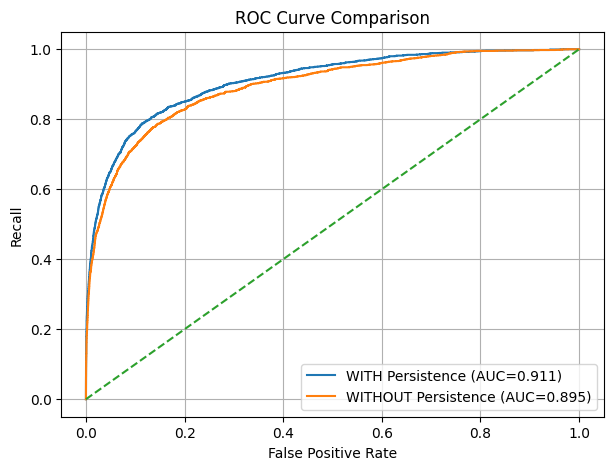

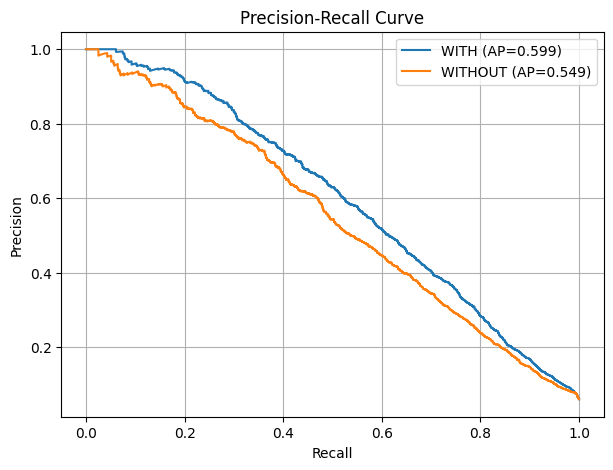

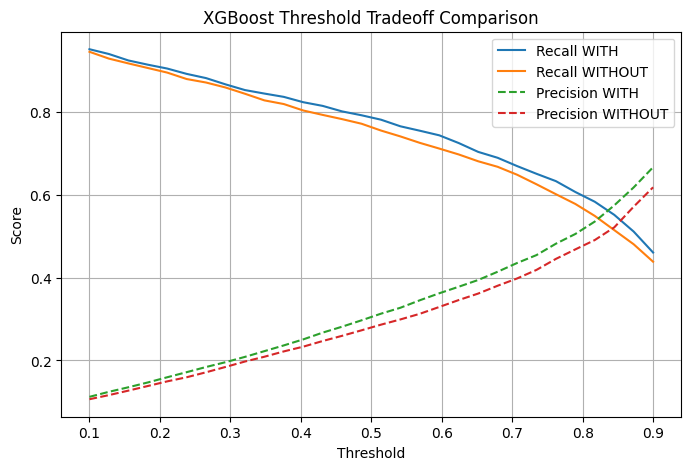

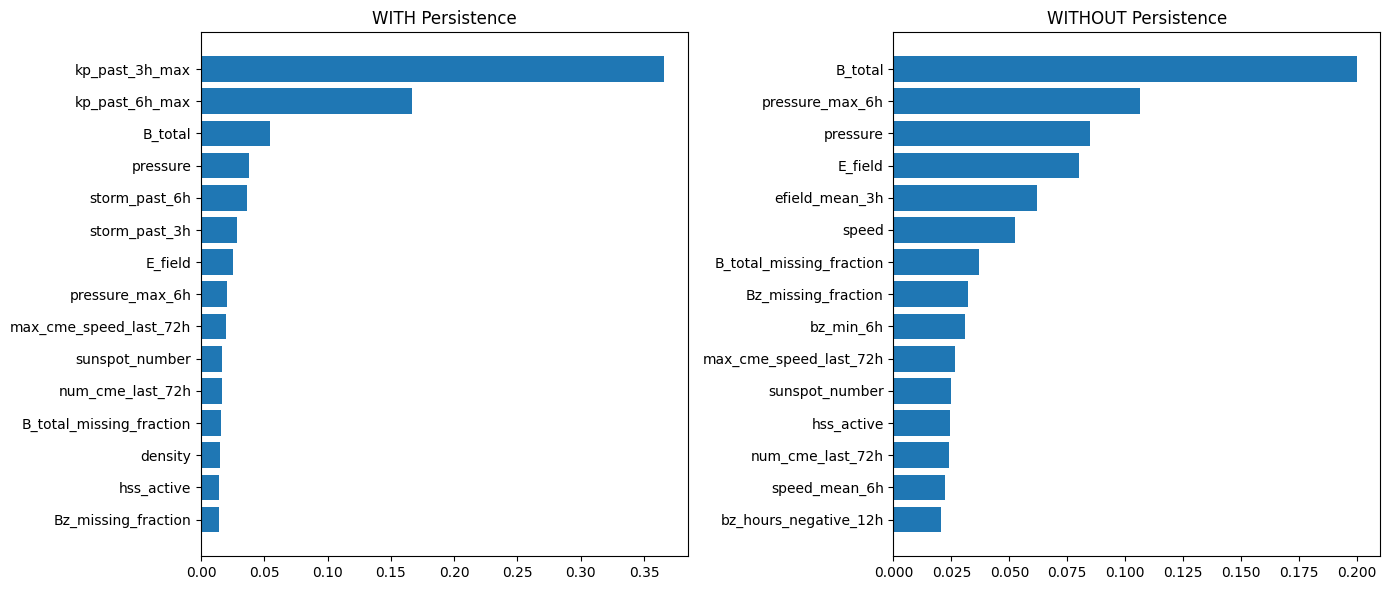

In [6]:
# ------------------------------------------------------------ #
# Running all plots
# ------------------------------------------------------------ #
# ROC
plot_roc_comparison(y_test_p, probs_with, y_test_np, probs_without)

# Precision-Recall
plot_pr_comparison(y_test_p, probs_with, y_test_np, probs_without)

# Threshold Comparison
plot_threshold_comparison(df_with, df_without)

# Feature Importance
plot_feature_importance_comparison(
    xgb_with_persistence,
    xgb_without_persistence,
    X_train_p,
    X_train_np
)

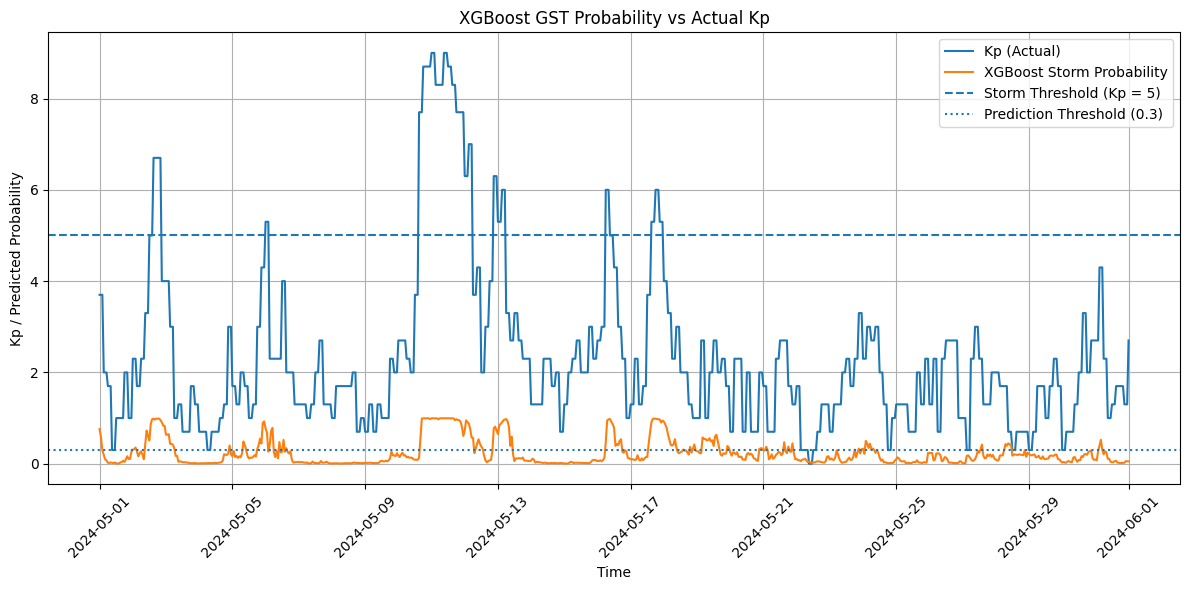

In [7]:
# ------------------------------------------------------------ #
# Time Series: Actual Kp vs XGBoost Storm Probability
# ------------------------------------------------------------ #

# Rebuild the test portion of master so it lines up with X_test_p/probs_with
test_master = master[master["datetime"] >= "2022-01-01"].copy()

# Add XGBoost probabilities to the test dataframe
test_master["xgb_prob"] = probs_with

# Select a short time window for clarity
# We use 2024-05 to 2024-06 just as a sample
sample = test_master[
    (test_master["datetime"] >= "2024-05-01") &
    (test_master["datetime"] <= "2024-06-01")
]

plt.figure(figsize=(12, 6))

# Actual Kp
plt.plot(
    sample["datetime"],
    sample["Kp_omni"],
    label="Kp (Actual)"
)

# XGBoost storm probability
plt.plot(
    sample["datetime"],
    sample["xgb_prob"],
    label="XGBoost Storm Probability"
)

# Storm Kp threshold
plt.axhline(
    y=5,
    linestyle="--",
    label="Storm Threshold (Kp = 5)"
)

# ML probability threshold
plt.axhline(
    y=0.3,
    linestyle=":",
    label="Prediction Threshold (0.3)"
)

plt.xlabel("Time")
plt.ylabel("Kp / Predicted Probability")
plt.title("XGBoost GST Probability vs Actual Kp")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

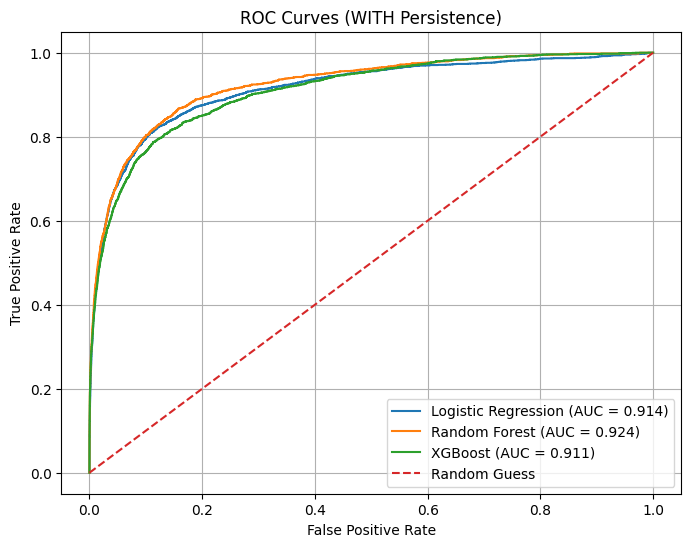

In [11]:
# ------------------------------------------------------------
# ROC-AUC Curves for All Three Models (WITH persistence)
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

models = {
    "Logistic Regression": log_with_persistence,
    "Random Forest": rf_with_persistence,
    "XGBoost": xgb_with_persistence
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test_p)[:, 1]

    fpr, tpr, _ = roc_curve(y_test_p, y_prob)
    auc_score = roc_auc_score(y_test_p, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (WITH Persistence)")
plt.legend()
plt.grid()
plt.show()

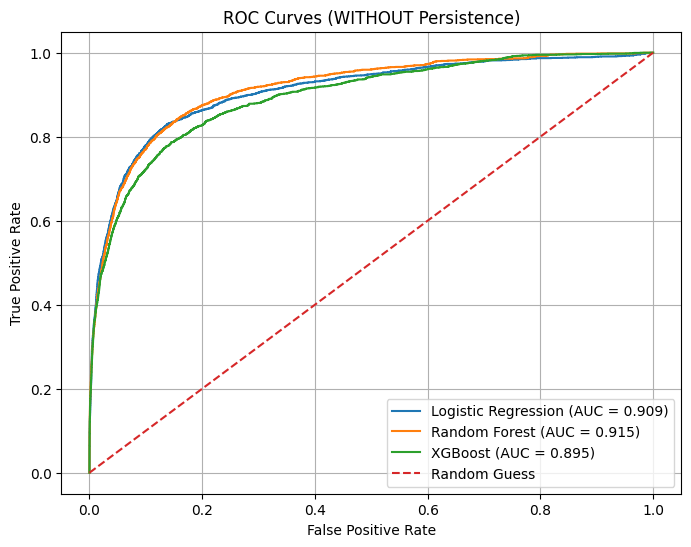

In [10]:
# ------------------------------------------------------------
# ROC-AUC Curves for All Three Models (WITHOUT persistence)
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))

models_np = {
    "Logistic Regression": log_without_persistence,
    "Random Forest": rf_without_persistence,
    "XGBoost": xgb_without_persistence
}

for name, model in models_np.items():

    y_prob = model.predict_proba(X_test_np)[:, 1]

    fpr, tpr, _ = roc_curve(y_test_np, y_prob)
    auc_score = roc_auc_score(y_test_np, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (WITHOUT Persistence)")
plt.legend()
plt.grid()
plt.show()